# Load

Loaded cached graph: cache\lithuania_corridor.graphml


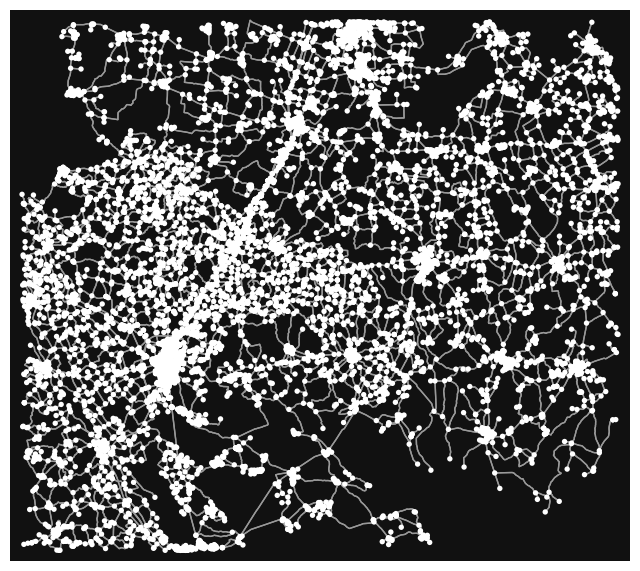

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
import copy
from pathlib import Path
import osmnx as ox
import leafmap

# Config
origin_name = "Seirijai, Lithuania"
destination_name = "Simnas, Lithuania"

west, south, east, north = 22.60, 53.85, 23.95, 54.55
zoom = 11

# Cache
cache_dir = Path("cache")
cache_dir.mkdir(exist_ok=True)

graph_path = cache_dir / "lithuania_corridor.graphml"

# Load graph
if graph_path.exists():
    G_base = ox.load_graphml(graph_path)
    print(f"Loaded cached graph: {graph_path}")
else:
    G_base = ox.graph_from_bbox(
        (west, south, east, north),
        network_type="drive",
        simplify=True,
    )
    ox.save_graphml(G_base, graph_path)
    print(f"Downloaded and cached graph: {graph_path}")

# Locations
origin = ox.geocode(origin_name)
destination = ox.geocode(destination_name)

orig_node = ox.distance.nearest_nodes(G_base, X=origin[1], Y=origin[0])
dest_node = ox.distance.nearest_nodes(G_base, X=destination[1], Y=destination[0])

ox.plot.plot_graph(G_base)

# Enrich

In [3]:
G_ready = G_base

# Assign speed, if not present default on road type.
G_ready = ox.add_edge_speeds(G_ready)

# Length / speed
G_ready = ox.add_edge_travel_times(G_ready)

# Add road type attributes
for _, _, _, d in G_ready.edges(keys=True, data=True):
    h = d.get("highway", "")

    d["is_main_road"] = h in ["primary", "secondary", "tertiary"]
    d["is_residential"] = h == "residential"
   

In [5]:
FLEET = {
    "light_wheeled": {
        "type": "light_wheeled",
        "weight_t": 3.5,
        "width_m": 2.0,
        "height_m": 2.2,
        "length_m": 5.0,
        "speed_penalty_factor": 1.0,
    },
    "heavy_wheeled": {
        "type": "heavy_wheeled",
        "weight_t": 18.0,
        "width_m": 2.8,
        "height_m": 3.5,
        "length_m": 9.0,
        "speed_penalty_factor": 0.8,
    },
    "tracked": {
        "type": "tracked",
        "weight_t": 30.0,
        "width_m": 3.2,
        "height_m": 3.0,
        "length_m": 7.5,
        "speed_penalty_factor": 0.6,
    },
}

In [ ]:
# Choke points

# betweenness centrality
# bridge in graph theory
# articulation points
# flow but n^3

In [6]:
def edge_cost_for_vehicle(data, vehicle):
    cost = data["length"]

    hw = data.get("highway")
    if isinstance(hw, list):
        hw = hw[0]

    # Hard constraints
    maxweight = data.get("maxweight")
    if maxweight is not None:
        try:
            if vehicle["weight_t"] > float(maxweight):
                return float("inf")
        except:
            pass

    maxheight = data.get("maxheight")
    if maxheight is not None:
        try:
            if vehicle["height_m"] > float(maxheight):
                return float("inf")
        except:
            pass

    # Soft constraints
    if data.get("bridge") == "yes" and vehicle["weight_t"] > 15:
        cost *= 1.5

    if data.get("lanes") == "1" and vehicle["width_m"] > 2.5:
        cost *= 1.3

    if hw in ["track", "path"] and vehicle["type"] == "heavy_wheeled":
        cost *= 1.8

    if hw in ["residential", "service"] and vehicle["length_m"] > 8:
        cost *= 1.2

    return cost

In [7]:
for u, v, k, data in G_ready.edges(keys=True, data=True):
    for name, vehicle in FLEET.items():
        data[f"cost_{name}"] = edge_cost_for_vehicle(data, vehicle)

# Solve

In [8]:
def solve_route(G, vehicle_type="light_wheeled"):
    weight = f"cost_{vehicle_type}"
    route = ox.routing.shortest_path(G, orig_node, dest_node, weight=weight)
    route_gdf = ox.routing.route_to_gdf(G, route, weight=weight)
    return route, route_gdf


def penalize_route(G, route, factor=4.0, vehicle_type="light_wheeled"):
    weight = f"cost_{vehicle_type}"

    for u, v in zip(route[:-1], route[1:]):
        edge_dict = G.get_edge_data(u, v)
        if edge_dict is None:
            continue

        for key, data in edge_dict.items():
            if weight in data:
                data[weight] *= factor

    return G

# Draw

In [9]:
def draw_routes(route_gdfs, labels=None):
    center = (
        (origin[0] + destination[0]) / 2,
        (origin[1] + destination[1]) / 2,
    )

    m = leafmap.Map(center=center, zoom=zoom)

    colors = ["red", "orange", "purple", "blue", "green"]

    for i, gdf in enumerate(route_gdfs):
        m.add_gdf(
            gdf,
            layer_name=labels[i] if labels else f"Route {i+1}",
            style={
                "color": colors[i],
                "weight": max(3, 7 - i),
                "opacity": 0.75,
            },
        )
    return m

# Experiment

In [10]:
G = copy.deepcopy(G_ready)

route1, gdf1 = solve_route(G, vehicle_type="light_wheeled")
draw_routes([gdf1], ["Baseline"])

Map(center=[54.308475900000005, 23.72954645], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom…

In [11]:
G = copy.deepcopy(G_base)

route1, gdf1 = solve_route(G,vehicle_type="heavy_wheeled" )
G = penalize_route(G, route1, vehicle_type="heavy_wheeled")

route2, gdf2 = solve_route(G,vehicle_type="heavy_wheeled")
G = penalize_route(G, route2, vehicle_type="heavy_wheeled")

route3, gdf3 = solve_route(G, vehicle_type="heavy_wheeled")
G = penalize_route(G, route3,vehicle_type="heavy_wheeled")

route4, gdf4 = solve_route(G, vehicle_type="heavy_wheeled")
G = penalize_route(G, route4, vehicle_type="heavy_wheeled")

route5, gdf5 = solve_route(G, vehicle_type="heavy_wheeled")

draw_routes([gdf1, gdf2, gdf3, gdf4, gdf5], ["Route 1", "Route 2", "Route 3", "Route 4", "Route 5"])

Map(center=[54.308475900000005, 23.72954645], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom…